# 5.1 Supervised Learning

## Konsep
Supervised Learning adalah metode machine learning yang menggunakan data berlabel.
Model belajar dari data input (X) dan target (y).

---

## Studi Kasus: Prediksi Kelulusan Mahasiswa

Sebuah kampus ingin memprediksi apakah mahasiswa akan Lulus (1) atau Tidak Lulus (0).

Faktor yang digunakan:
- Jam belajar per minggu
- Persentase kehadiran
- Nilai tugas
- Nilai UTS

Dataset sintetis dibuat sebanyak 1000 mahasiswa.

Tujuan: Model dapat memprediksi kelulusan mahasiswa baru berdasarkan datanya.

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate synthetic dataset
np.random.seed(42)
n = 1000

jam_belajar = np.random.randint(1, 20, n)
kehadiran = np.random.randint(50, 100, n)
nilai_tugas = np.random.randint(40, 100, n)
nilai_uts = np.random.randint(40, 100, n)

# Aturan sederhana untuk kelulusan
lulus = (jam_belajar + kehadiran/10 + nilai_tugas/10 + nilai_uts/10 > 30).astype(int)

X = np.column_stack((jam_belajar, kehadiran, nilai_tugas, nilai_uts))
y = lulus

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.99


# 5.2 Unsupervised Learning

## Konsep
Unsupervised Learning tidak menggunakan label.
Model mencari pola tersembunyi dalam data.

Metode yang digunakan pada studi kasus ini adalah Clustering (K-Means).

---

## Studi Kasus: Pola Aktivitas Mahasiswa di Platform E-Learning

Sebuah kampus ingin menganalisis aktivitas mahasiswa berdasarkan:
- Jam belajar per minggu
- Jumlah tugas yang dikumpulkan
- Frekuensi login per minggu

Data diambil dari 1000 mahasiswa.

Karena data dunia nyata tidak selalu teratur,
maka dataset dibuat dengan:
- Variasi perilaku mahasiswa
- Noise acak
- Beberapa outlier

Tujuan:
Mengetahui pola aktivitas tanpa label kategori sebelumnya.

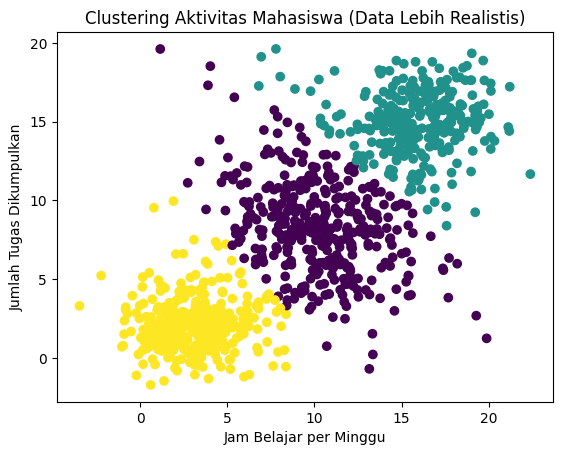

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(42)

n = 1000

# Buat beberapa tipe mahasiswa secara realistis

# 1. Mahasiswa kurang aktif
jam1 = np.random.normal(3, 2, 300)
tugas1 = np.random.normal(2, 1.5, 300)

# 2. Mahasiswa cukup aktif
jam2 = np.random.normal(10, 3, 400)
tugas2 = np.random.normal(8, 3, 400)

# 3. Mahasiswa sangat aktif
jam3 = np.random.normal(16, 2, 250)
tugas3 = np.random.normal(15, 2, 250)

# 4. Outlier (tidak teratur)
jam4 = np.random.uniform(0, 20, 50)
tugas4 = np.random.uniform(0, 20, 50)

# Gabungkan semua
jam_belajar = np.concatenate([jam1, jam2, jam3, jam4])
jumlah_tugas = np.concatenate([tugas1, tugas2, tugas3, tugas4])

X = np.column_stack((jam_belajar, jumlah_tugas))

# Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Visualisasi
plt.scatter(jam_belajar, jumlah_tugas, c=labels)
plt.xlabel("Jam Belajar per Minggu")
plt.ylabel("Jumlah Tugas Dikumpulkan")
plt.title("Clustering Aktivitas Mahasiswa (Data Lebih Realistis)")
plt.show()

# 5.3 Semi-Supervised Learning

## Konsep
Semi-Supervised Learning adalah metode pembelajaran mesin
yang menggunakan sedikit data berlabel dan banyak data tidak berlabel.

Metode ini digunakan ketika:
- Pelabelan data mahal atau memakan waktu
- Tetapi data mentah sangat banyak

---

## Studi Kasus: Deteksi Mahasiswa Berisiko Tidak Lulus

Sebuah kampus ingin mendeteksi mahasiswa yang berisiko tidak lulus.

Data yang tersedia:
- Jam belajar per minggu
- Persentase kehadiran
- Nilai tugas rata-rata
- Nilai UTS

Total data: 1000 mahasiswa

Masalah:
Hanya 100 mahasiswa yang sudah diketahui status akhirnya (lulus / tidak).
Sisanya belum diketahui karena semester belum selesai.

Tujuan:
Menggunakan sedikit data berlabel untuk membantu mengklasifikasikan
mahasiswa lain yang belum memiliki label.

In [7]:
import numpy as np
from sklearn.semi_supervised import LabelSpreading
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)

n = 1000

# Generate data realistis
jam_belajar = np.random.normal(8, 4, n)
kehadiran = np.random.normal(75, 15, n)
nilai_tugas = np.random.normal(70, 15, n)
nilai_uts = np.random.normal(65, 20, n)

# Batasi nilai agar masuk akal
jam_belajar = np.clip(jam_belajar, 0, 20)
kehadiran = np.clip(kehadiran, 40, 100)
nilai_tugas = np.clip(nilai_tugas, 0, 100)
nilai_uts = np.clip(nilai_uts, 0, 100)

# Buat aturan realistis untuk kelulusan (tidak terlalu sempurna)
score = (0.2*jam_belajar +
         0.3*kehadiran +
         0.25*nilai_tugas +
         0.25*nilai_uts)

lulus = (score > 65).astype(int)

X = np.column_stack((jam_belajar,
                     kehadiran,
                     nilai_tugas,
                     nilai_uts))

# Normalisasi (penting untuk semi-supervised)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Hanya 100 data diberi label
y = np.full(n, -1)
y[:100] = lulus[:100]

# Model Semi-Supervised
model = LabelSpreading()
model.fit(X, y)

# Hasil propagasi label
predicted_labels = model.transduction_

print("Total mahasiswa:", n)
print("Data awal yang berlabel:", 100)
print("Distribusi hasil klasifikasi:")
print("Lulus:", np.sum(predicted_labels == 1))
print("Tidak Lulus:", np.sum(predicted_labels == 0))

Total mahasiswa: 1000
Data awal yang berlabel: 100
Distribusi hasil klasifikasi:
Lulus: 162
Tidak Lulus: 838


# 5.4 Reinforcement Learning

## Konsep Dasar

Reinforcement Learning adalah metode belajar melalui pengalaman.

Agen:
Mesin minuman otomatis

Environment:
Pembeli yang datang setiap hari

State:
Jumlah stok minuman (sedikit / cukup / banyak)

Action:
Tambah stok sedikit atau tambah stok banyak

Reward:
+10 jika stok cukup (tidak kehabisan & tidak berlebihan)
-10 jika kehabisan stok
-5 jika stok terlalu banyak (boros)

Tujuan:
Mesin belajar berapa stok yang optimal agar tidak rugi.

In [9]:
import numpy as np

np.random.seed(42)

# State:
# 0 = stok sedikit
# 1 = stok cukup
# 2 = stok banyak

n_states = 3

# Action:
# 0 = tambah sedikit
# 1 = tambah banyak
n_actions = 2

# Q-table
Q = np.zeros((n_states, n_actions))

alpha = 0.1      # learning rate
gamma = 0.9      # diskon masa depan
epsilon = 0.2    # eksplorasi

episodes = 1000

for episode in range(episodes):
    
    state = np.random.randint(0, 3)  # kondisi awal acak
    
    # pilih aksi (explore atau exploit)
    if np.random.rand() < epsilon:
        action = np.random.randint(0, 2)
    else:
        action = np.argmax(Q[state])
    
    # Simulasi permintaan pembeli (realistis)
    demand = np.random.choice(["rendah", "normal", "tinggi"])
    
    # Tentukan reward berdasarkan kondisi nyata
    if state == 0 and demand == "tinggi":
        reward = -10   # kehabisan
        next_state = 0
        
    elif state == 2 and demand == "rendah":
        reward = -5    # terlalu banyak stok
        next_state = 2
        
    else:
        reward = 10    # stok pas
        next_state = 1
    
    # Update Q-table
    Q[state, action] += alpha * (
        reward + gamma * np.max(Q[next_state]) - Q[state, action]
    )

print("Q-Table setelah belajar:\n")
print(Q)

print("\nStrategi terbaik tiap kondisi stok:")
print("Stok sedikit  →", np.argmax(Q[0]))
print("Stok cukup    →", np.argmax(Q[1]))
print("Stok banyak   →", np.argmax(Q[2]))

Q-Table setelah belajar:

[[85.74509601 88.74017551]
 [95.70047067 84.8035151 ]
 [74.57813313 87.49679862]]

Strategi terbaik tiap kondisi stok:
Stok sedikit  → 1
Stok cukup    → 0
Stok banyak   → 1


## Interpretasi Hasil

Dari Q-table kita bisa melihat:

Jika stok sedikit → mesin mungkin memilih tambah banyak.
Jika stok banyak → mesin mungkin memilih tambah sedikit.
Jika stok cukup → mesin cenderung menjaga stabil.

Artinya mesin sudah belajar strategi terbaik
berdasarkan pengalaman reward yang diterima.